In [17]:
import os
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.nn.functional as F

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
torch.cuda.empty_cache()

In [20]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class MultimodalDataset(Dataset):
    def __init__(self, base_dir, tokenizer, transform=None):
        self.image_dir = Path(base_dir) / "spectograms"
        self.text_dir = Path(base_dir) / "lyrics"
        self.tokenizer = tokenizer
        self.transform = transform

        # Wczytaj etykiety
        labels_path = Path(base_dir) / "classes.txt"
        with open(labels_path, "r") as f:
            self.labels = [line.strip() for line in f.readlines()]

        # Posortuj pliki obrazów według numeru ID (NNN)
        image_paths = sorted(self.image_dir.glob("*_mel.png"), key=lambda p: int(p.stem.split("_")[0]))
        self.file_ids = [img.stem.split("_")[0] for img in image_paths]  # np. "041", "042", ...

        assert len(self.file_ids) == len(self.labels), \
            f"Liczba obrazów ({len(self.file_ids)}) nie zgadza się z liczbą etykiet ({len(self.labels)})"

        # Przygotuj mapowania klas
        self.unique_classes = sorted(set(self.labels))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.unique_classes)}
        self.idx_labels_dict = {file_id: self.class_to_idx[label] for file_id, label in zip(self.file_ids, self.labels)}

        print(f"Załadowano {len(self.file_ids)} obrazów z {base_dir}")

    def __len__(self):
        return len(self.file_ids)
    
    def get_class_names(self):
        return [cls for cls, _ in sorted(self.class_to_idx.items(), key=lambda item: item[1])]

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]

        # Obraz
        image_path = self.image_dir / f"{file_id}_mel.png"
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Tekst (jeśli istnieje)
        text_path = self.text_dir / f"{file_id}.txt"
        if text_path.exists():
            with open(text_path, "r", encoding="utf-8") as f:
                text = f.read()
        else:
            text = ""  # Pusty tekst, jeśli brak pliku

        inputs = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        label = self.idx_labels_dict[file_id]

        return {
            "image": image,
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "label": label
        }



In [21]:
# === TRANSFORMS & TOKENIZER ===
transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [22]:
base_path = "../dataset"
train_dataset = MultimodalDataset(base_path + "/train", tokenizer, transform)
val_dataset = MultimodalDataset(base_path + "/val", tokenizer, transform)
test_dataset = MultimodalDataset(base_path + "/test", tokenizer, transform)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Załadowano 611 obrazów z ../dataset/train
Załadowano 76 obrazów z ../dataset/val
Załadowano 77 obrazów z ../dataset/test


In [23]:
len(train_dataset), len(val_dataset), len(test_dataset)

(611, 76, 77)

In [24]:
unique_classes = train_dataset.get_class_names()
print("Znalezione klasy:", unique_classes)

Znalezione klasy: ['negative', 'nostalgic', 'positive']


In [25]:
# === MODEL ===
class MultimodalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.cnn = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(768 + 784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask, images):
        text_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_output.pooler_output

        image_feat = self.cnn(images)

        combined = torch.cat((text_feat, image_feat), dim=1)
        out = self.fc(combined)
        return out


In [26]:
# tu jest wersja z optymalizacją optuną optuna


# def objective(trial):
#     import os
#     os.makedirs("saved_models", exist_ok=True)

#     # Proponowane hiperparametry
#     lr = trial.suggest_loguniform("lr", 1e-5, 1e-3)
#     batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
#     num_epochs = trial.suggest_int("num_epochs", 3, 8)

#     # Przygotowanie danych z nowym batch_size
#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#     # Model i optymalizator
#     model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()

#     # Trening
#     for epoch in range(num_epochs):
#         model.train()
#         for batch in train_loader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             images = batch['image'].to(device)
#             labels = batch['label'].to(device)

#             optimizer.zero_grad()
#             outputs = model(input_ids, attention_mask, images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             torch.cuda.empty_cache()

#     # Walidacja
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for batch in val_loader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             images = batch['image'].to(device)
#             labels = batch['label'].to(device)

#             outputs = model(input_ids, attention_mask, images)
#             _, predicted = torch.max(outputs, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#     accuracy = correct / total

#     # Zapisz model
#     model_path = f"saved_models/model_trial{trial.number}_acc{accuracy:.4f}.pt"
#     torch.save(model.state_dict(), model_path)

#     return accuracy


In [27]:
# import optuna

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20)

# print("Best hyperparameters:")
# print(study.best_params)


In [ ]:
# tu jest wersja z param gridem


# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader
# import itertools
# import os

# # Siatka hiperparametrów
# learning_rates = [1e-5, 5e-5, 1e-4]
# batch_sizes = [16, 32, 64]
# num_epochs_list = [4, 5]

# # Utwórz folder na modele
# os.makedirs("saved_models", exist_ok=True)

# # Numer próby
# trial_num = 0

# # Przeszukiwanie siatki
# for lr, batch_size, num_epochs in itertools.product(learning_rates, batch_sizes, num_epochs_list):
#     print(f"\n=== Trial {trial_num}: LR={lr}, Batch={batch_size}, Epochs={num_epochs} ===")

#     # Loadery z batch_size
#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#     # Model i optymalizator
#     model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()

#     try:
#         for epoch in range(num_epochs):
#             model.train()
#             total_loss = 0
#             for batch in train_loader:
#                 input_ids = batch['input_ids'].to(device)
#                 attention_mask = batch['attention_mask'].to(device)
#                 images = batch['image'].to(device)
#                 labels = batch['label'].to(device)

#                 optimizer.zero_grad()
#                 outputs = model(input_ids, attention_mask, images)
#                 loss = criterion(outputs, labels)
#                 loss.backward()
#                 optimizer.step()
#                 total_loss += loss.item()

#                 torch.cuda.empty_cache()

#             avg_loss = total_loss / len(train_loader)
#             print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

#         # Walidacja
#         model.eval()
#         correct = 0
#         total = 0
#         with torch.no_grad():
#             for batch in val_loader:
#                 input_ids = batch['input_ids'].to(device)
#                 attention_mask = batch['attention_mask'].to(device)
#                 images = batch['image'].to(device)
#                 labels = batch['label'].to(device)

#                 outputs = model(input_ids, attention_mask, images)
#                 _, predicted = torch.max(outputs, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()

#         accuracy = correct / total
#         print(f"Validation Accuracy: {accuracy:.4f}")

#         # Zapis modelu
#         torch.save(model.state_dict(), f"saved_models/model_trial{trial_num}_acc{accuracy:.4f}.pt")

#     except torch.cuda.OutOfMemoryError:
#         print("Out of Memory – pomijam tę kombinację.")
#         torch.cuda.empty_cache()

#     trial_num += 1


In [29]:
# === TRAINING ===
model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # Walidacja
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {correct/total:.4f}")

Epoch 1/5, Loss: 1.0793
Validation Accuracy: 0.4474


KeyboardInterrupt: 


Test classification report:
              precision    recall  f1-score   support

    negative       0.15      0.20      0.17        20
   nostalgic       0.33      0.17      0.23        23
    positive       0.44      0.50      0.47        34

    accuracy                           0.32        77
   macro avg       0.31      0.29      0.29        77
weighted avg       0.33      0.32      0.32        77



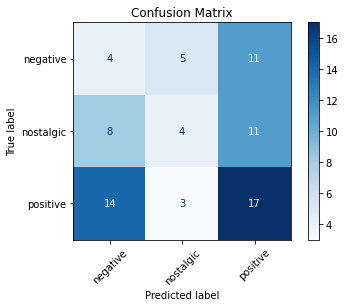

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === TEST ===
from sklearn.metrics import classification_report

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, images)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

print("\nTest classification report:")
print(classification_report(test_labels, test_preds, target_names=unique_classes))

# === CONFUSION MATRIX ===
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

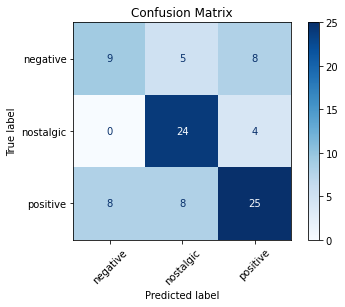

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === CONFUSION MATRIX ===
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
